In [ ]:
# !pip install -q kaggle

In [ ]:
# from google.colab import files
# files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sayantanchaudhuri09","key":"ab4a11f61c118ae64484de63df7ee880"}'}

In [ ]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !ls ~/.kaggle

kaggle.json


In [ ]:
# !kaggle datasets download -d riyaelizashaju/skin-disease-classification-image-dataset
# import zipfile
# with zipfile.ZipFile("skin-disease-classification-image-dataset.zip", 'r') as zip_ref:
#     zip_ref.extractall("skin_disease_dataset")

Dataset URL: https://www.kaggle.com/datasets/riyaelizashaju/skin-disease-classification-image-dataset
License(s): unknown


In [1]:
import os
dataset_dir = r"C:\experiment_mini\skin_disease_dataset\Split_smol"
train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")
class_names = os.listdir(train_dir)
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

Classes: ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']
Number of classes: 9


C:\Users\KIIT\AppData\Local\Temp\ipykernel_24564\795157168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_class_counts.keys()), y=list(train_class_counts.values()), palette='viridis')


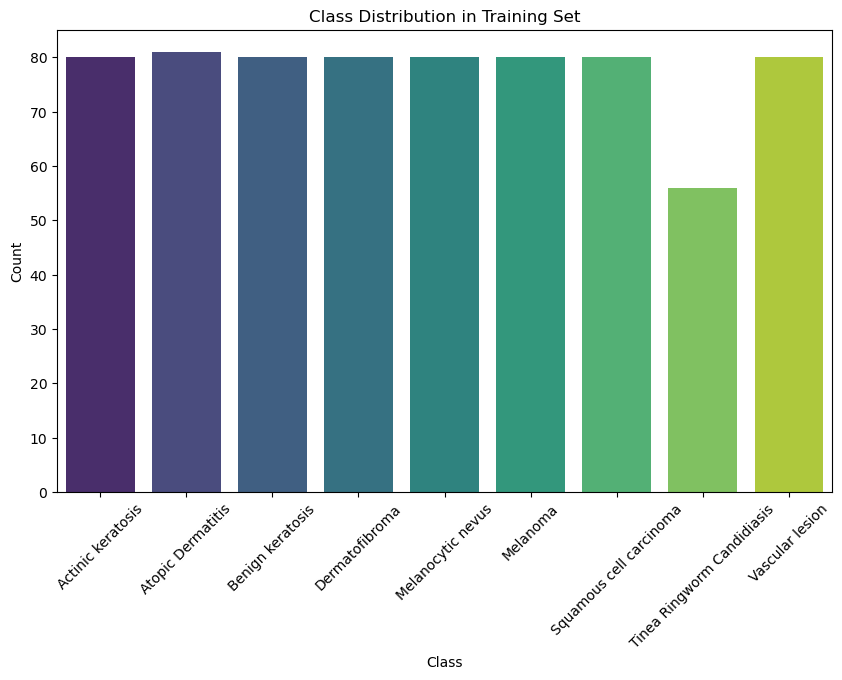

In [2]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
train_class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(train_class_counts.keys()), y=list(train_class_counts.values()), palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

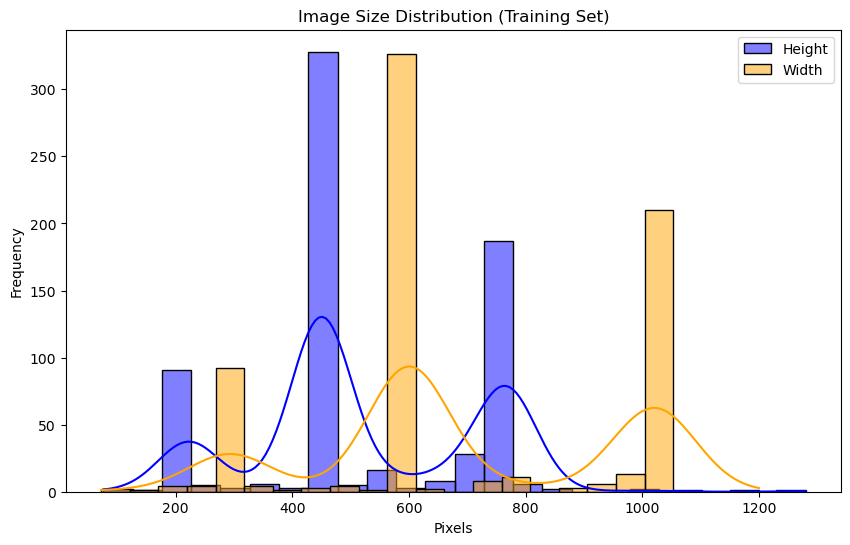

In [3]:
image_shapes = []
for cls in class_names:
    cls_folder = os.path.join(train_dir, cls)
    for img_file in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, img_file)
        img = plt.imread(img_path)
        image_shapes.append(img.shape[:2])  # Height and Width

heights, widths = zip(*image_shapes)
plt.figure(figsize=(10, 6))
sns.histplot(heights, kde=True, color='blue', label='Height', binwidth=50)
sns.histplot(widths, kde=True, color='orange', label='Width', binwidth=50)
plt.title('Image Size Distribution (Training Set)')
plt.xlabel('Pixels')
plt.ylabel('Frequency')
plt.legend()
plt.show()


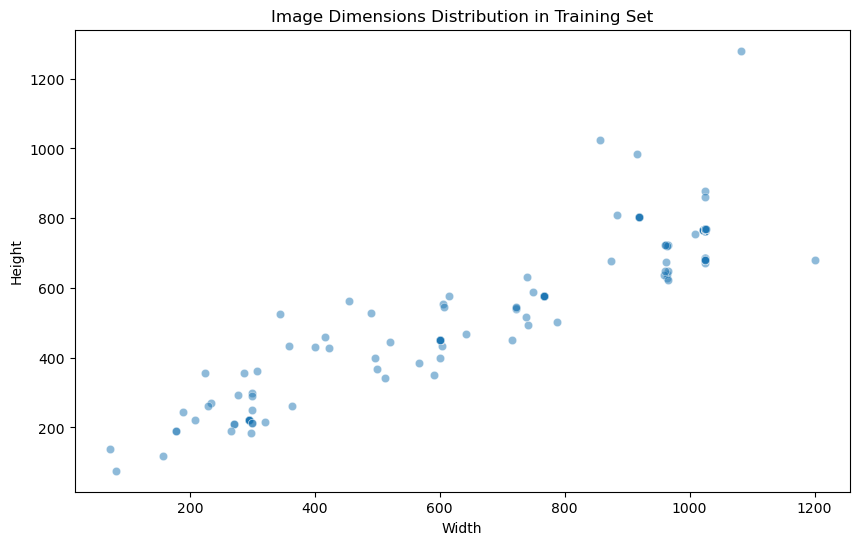

In [4]:
heights, widths = zip(*image_shapes)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=widths, y=heights, alpha=0.5)
plt.title('Image Dimensions Distribution in Training Set')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

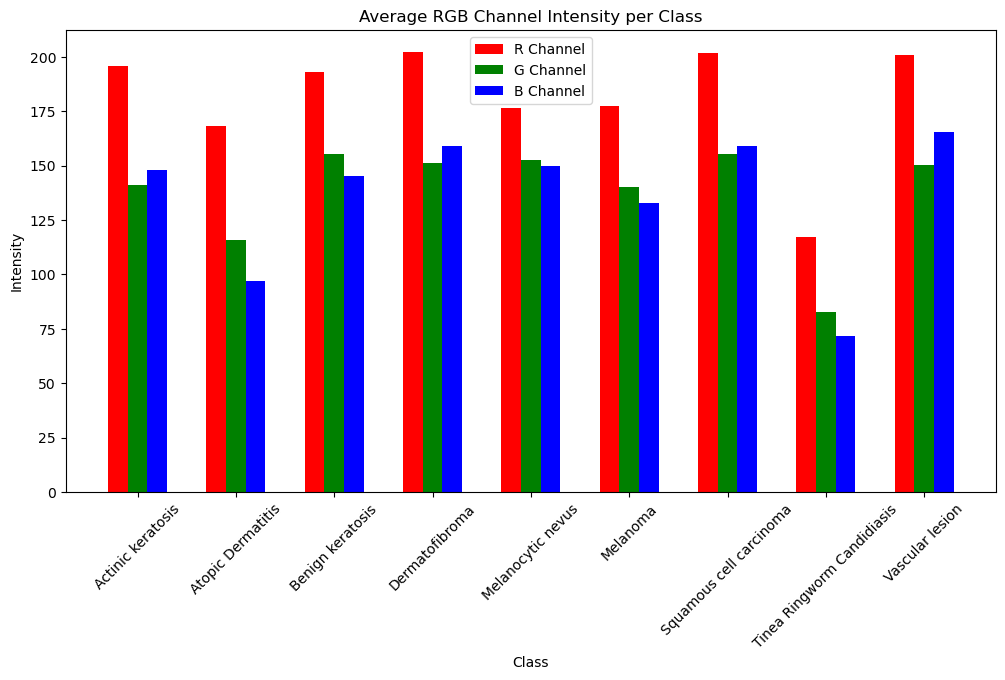

In [5]:
import numpy as np

rgb_means = {cls: [] for cls in class_names}
for cls in class_names:
    cls_folder = os.path.join(train_dir, cls)
    for img_file in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, img_file)
        img = plt.imread(img_path)
        if img.ndim == 3:  # Ensure it's a color image
            rgb_means[cls].append(np.mean(img, axis=(0, 1)))

rgb_means_avg = {cls: np.mean(rgb_means[cls], axis=0) for cls in class_names}
colors = ['r', 'g', 'b']
x_ticks = np.arange(len(class_names))

plt.figure(figsize=(12, 6))
for i, color in enumerate(colors):
    plt.bar(x_ticks + i * 0.2, [rgb_means_avg[cls][i] for cls in class_names], width=0.2, color=color, label=f'{color.upper()} Channel')

plt.xticks(x_ticks + 0.2, class_names, rotation=45)
plt.title('Average RGB Channel Intensity per Class')
plt.xlabel('Class')
plt.ylabel('Intensity')
plt.legend()
plt.show()


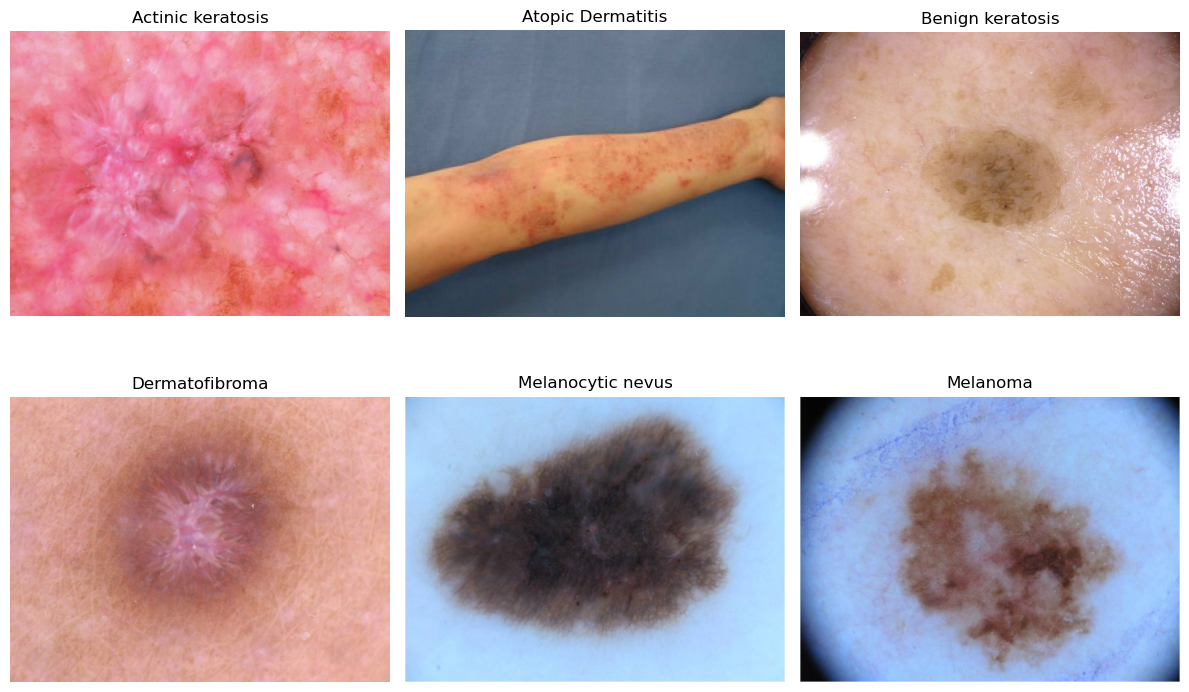

In [6]:
from matplotlib.image import imread

plt.figure(figsize=(12, 8))
for i, cls in enumerate(class_names[:6]):
    img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
    img = imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [7]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import tensorflow as tf
print(tf.__version__)


2.19.0


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(rescale=1./255)
batch_size = 32
target_size = (224, 224)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 697 images belonging to 9 classes.


Found 181 images belonging to 9 classes.


In [11]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
num_classes = len(class_names)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,046,729 (26.88 MB)

 Trainable params: 6,963,081 (26.56 MB)

 Non-trainable params: 83,648 (326.75 KB)

None


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
def scheduler(epoch, lr):
    if epoch < 5:
        return lr
    else:
        return lr * 0.5
lr_schedule = LearningRateScheduler(scheduler)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    callbacks=[early_stop, lr_schedule]
)

c:\Users\KIIT\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 329s 12s/step - accuracy: 0.3696 - loss: 2.0668 - val_accuracy: 0.1326 - val_loss: 7.0049 - learning_rate: 0.0010
Epoch 2/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 253s 12s/step - accuracy: 0.6523 - loss: 0.9627 - val_accuracy: 0.1160 - val_loss: 18.6129 - learning_rate: 0.0010
Epoch 3/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 254s 12s/step - accuracy: 0.7378 - loss: 0.7985 - val_accuracy: 0.3315 - val_loss: 4.0547 - learning_rate: 0.0010
Epoch 4/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 252s 11s/step - accuracy: 0.6833 - loss: 0.7899 - val_accuracy: 0.2486 - val_loss: 3.5525 - learning_rate: 0.0010
Epoch 5/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 258s 12s/step - accuracy: 0.7596 - loss: 0.6810 - val_accuracy: 0.1657 - val_loss: 16.3524 - learning_rate: 0.0010
Epoch 6/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 279s 13s/step - accuracy: 0.8070 - loss: 0.5325 - val_accuracy: 0.5028 - val_loss: 1.8813 - learning_rate: 5.0000e-04
Epoch 7/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 291s 13s/step - accuracy: 0.8444 - loss: 0.4

In [13]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7971 - loss: 0.6923
Validation Accuracy: 80.66%


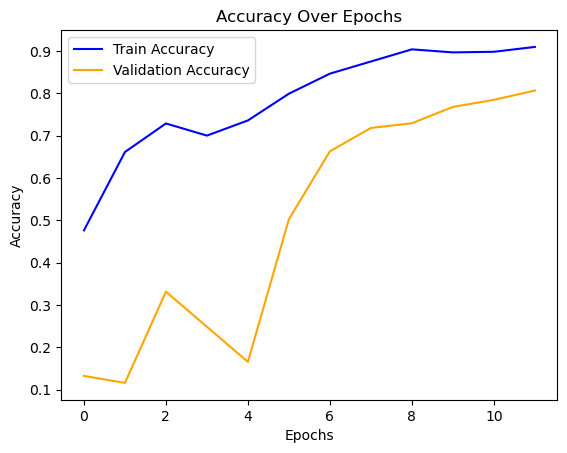

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.legend()
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()



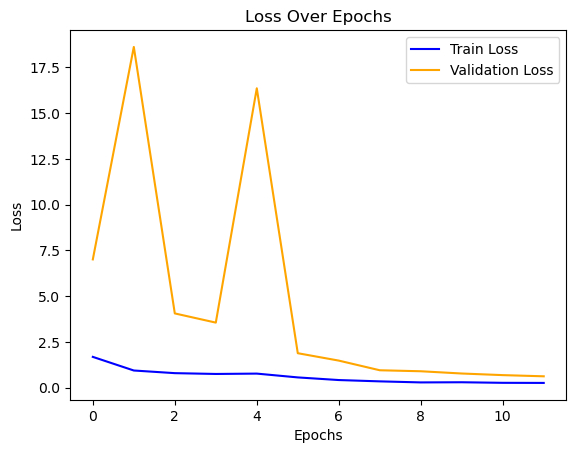

In [15]:
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.legend()
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [16]:
model.save('skin_disease_model.h5')
print("Model saved successfully.")

Model saved successfully.


In [17]:
import os

train_dir = "C:\\mini_project\\skin_disease_dataset\\Split_smol\\train"

# Recursively get all image paths from subdirectories
image_paths = []
for root, _, files in os.walk(train_dir):
    for file in files:
        if file.lower().endswith(('.png','.jpg','.jpeg')):
            image_paths.append(os.path.join(root,file))

# Print some paths to verify
print("Found images:",len(image_paths))
print(image_paths[:5])  # Print first 5 images


Found images: 697
['C:\\mini_project\\skin_disease_dataset\\Split_smol\\train\\Actinic keratosis\\ISIC_0024468.jpg', 'C:\\mini_project\\skin_disease_dataset\\Split_smol\\train\\Actinic keratosis\\ISIC_0024470.jpg', 'C:\\mini_project\\skin_disease_dataset\\Split_smol\\train\\Actinic keratosis\\ISIC_0024707.jpg', 'C:\\mini_project\\skin_disease_dataset\\Split_smol\\train\\Actinic keratosis\\ISIC_0024763.jpg', 'C:\\mini_project\\skin_disease_dataset\\Split_smol\\train\\Actinic keratosis\\ISIC_0024771.jpg']


In [18]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Select a valid image path from the list
if image_paths:
    image_path = image_paths[0]  # Load the first image

    # Load and preprocess the image
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Reshape for model input

    print("✅ Image loaded and preprocessed successfully.")
else:
    print("❌ No images found in the directory.")


✅ Image loaded and preprocessed successfully.


In [19]:
from tensorflow.keras.models import load_model
model = load_model('skin_disease_model.h5')
print("Model loaded successfully.")


Model loaded successfully.


In [20]:
import os

UPLOAD_FOLDER = "static/uploads"
os.makedirs(UPLOAD_FOLDER, exist_ok=True)  # Creates if not exists


In [21]:
class_names = ['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus','Melanoma','Squamous cell carcinoma','Tinea Ringworm Candidiasis', 'Vascular lesion']
import numpy as np
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: Squamous cell carcinoma


In [22]:
pip install flask tensorflow numpy pillow



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
